<div style="text-align: center;">

<h1 style="color:blue; font-size:50px; font-weight:bold;">
EXAMEN FINAL – MACHINE LEARNING
</h1>

<h2 style="color:blue; font-size:32px; font-weight:bold;">
CALLACHAND Muntasir
</h2>

</div>

## <span style="color:#00BFFF"><u>CONTEXTE PROFESSIONNEL</u></span>

FitNation, acteur majeur du fitness en France avec plus de 400 000 membres répartis dans 50 villes, se trouve à un tournant stratégique après avoir traversé trois phases clés :

* une forte croissance (2016-2019) portée par l'expansion de ses salles et de son application mobile
* une crise majeure liée au COVID-19 (2020-2021)
* et une reprise post-crise (depuis 2022) caractérisée par une volatilité accrue des adhérents.

Face à ce défi de fidélisation, mon intégration au sein de l'équipe Data en 2024 s'inscrit dans la volonté de la direction d'amorcer une transition *data-driven*. L'objectif de ce notebook est de poser les bases de modèles prédictifs (segmentation, ciblage, personnalisation) pour optimiser les décisions commerciales et sécuriser la relation client.

## <span style="color:#00BFFF"><u>MISSION</u></span>

Ma mission consiste à explorer les données clients de FitNation afin de construire deux modèles prédictifs à forte valeur ajoutée pour orienter les décisions commerciales et relationnelles de l'entreprise :

* **Objectif 1 (Régression) :** Estimer le revenu mensuel généré par client.
* **Objectif 2 (Classification) :** Anticiper le risque de résiliation (*churn*) afin de déployer des actions de rétention ciblées et personnalisées.

---

## <span style="color:darkblue"><u>Partie 1 : Exploration et Préparation des Données</u></span>

#### <u>**Importation modules**</u>


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score, f1_score

#### <u>**Chargement des données**</u>

In [57]:
df = pd.read_csv("INPUT/clients_2018_2023.csv")
df.head(5)

,id_client,age,anciennete_mois,nb_seances_moy_mois,abonnement_premium,coaching,satisfaction,revenu_mensuel,churn
0,1,42.0,31,2.7,0,1,4.8,61.29,0
1,2,36.0,53,5.9,1,0,6.1,74.91,0
2,3,44.0,34,2.9,0,1,5.2,59.89,0
3,4,53.0,38,5.4,0,0,7.4,54.76,0
4,5,35.0,57,5.0,0,1,8.9,60.95,0


#### <u>**Informations générales**</u>

In [58]:
df.shape

(10000, 9)

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_client            10000 non-null  int64  
 1   age                  9990 non-null   float64
 2   anciennete_mois      10000 non-null  int64  
 3   nb_seances_moy_mois  9990 non-null   float64
 4   abonnement_premium   10000 non-null  int64  
 5   coaching             10000 non-null  int64  
 6   satisfaction         9990 non-null   float64
 7   revenu_mensuel       9990 non-null   float64
 8   churn                10000 non-null  int64  
dtypes: float64(4), int64(5)
memory usage: 703.3 KB


In [60]:
df.describe().round(2)

,id_client,age,anciennete_mois,nb_seances_moy_mois,abonnement_premium,coaching,satisfaction,revenu_mensuel,churn
count,10000.00,9990.00,10000.00,9990.00,10000.00,10000.00,9990.00,9990.00,10000.00
mean,5000.50,37.58,36.35,5.04,0.39,0.25,5.70,70.07,0.06
std,2886.90,9.86,20.83,2.20,0.49,0.43,2.06,22.56,0.24
min,1.00,18.00,1.00,0.50,0.00,0.00,0.00,20.00,0.00
25%,2500.75,31.00,18.00,3.60,0.00,0.00,4.30,54.97,0.00
50%,5000.50,37.00,36.00,5.00,0.00,0.00,5.70,69.00,0.00
75%,7500.25,44.00,54.00,6.40,1.00,0.00,7.10,84.23,0.00
max,10000.00,150.00,72.00,100.00,1.00,1.00,10.00,999.00,1.00


In [61]:
df.isna().sum()

id_client               0
age                    10
anciennete_mois         0
nb_seances_moy_mois    10
abonnement_premium      0
coaching                0
satisfaction           10
revenu_mensuel         10
churn                   0
dtype: int64

<div style="border: 2px solid blue; padding: 10px; border-radius: 8px;">

Le jeu de données contient **10 000 lignes** (clients) et **9 colonnes** et présente une bonne qualité globale, avec seulement quelques valeurs manquantes (0,1 % des observations) sur certaines variables.

Les clients ont en moyenne **37,6 ans**, une ancienneté de **36 mois** et réalisent environ **5 séances par mois**. Environ **39 %** disposent d’un abonnement **premium** et **25 %** bénéficient d’un **coaching**. Le taux de **churn** est de **6 %**, ce qui indique un jeu de données déséquilibré avec une majorité de clients fidèles.

Les colonnes **churn** sera mis en type **category** et **age** en nombre entier. On ne mettra pas **abonnement_premium** et **coaching** en **category** car on voudra voire leur impact sur notre variable cible.

Enfin, quelques valeurs extrêmes (âge, nombre de séances ou revenu) devront être vérifiées avant l’entraînement des modèles.

</div>

#### <u>**Traitement des outliers**</u>


Outliers détectés pour age :
        age
179    65.0
209    70.0
478    68.0
755    64.0
1260  150.0
1453   64.0
1615   69.0
1934   64.0
1957   69.0
2035   65.0
2305   69.0
2506   67.0
2521   67.0
2574   64.0
2801   64.0
2895   70.0
3241   66.0
3716   70.0
3982   69.0
4047   66.0
4784   65.0
4870   68.0
4997   69.0
5157   67.0
5224   67.0
5673   66.0
5796   68.0
5808   65.0
5846   67.0
6058   64.0
6252   64.0
6350   65.0
6738   67.0
6891   70.0
6958   64.0
7096   65.0
7223   69.0
7330   67.0
7441   65.0
7624   65.0
7736   65.0
7783   64.0
7872   66.0
7874   66.0
8095   64.0
8165   67.0
8248   70.0
8311   64.0
8726   69.0
9258   65.0

Nombre d'outliers pour age : 50


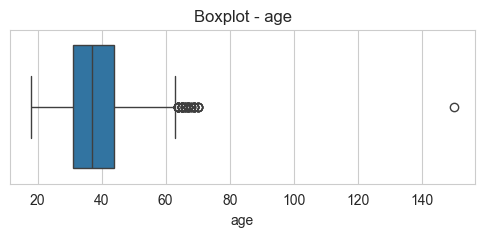


Outliers détectés pour nb_seances_moy_mois :
      nb_seances_moy_mois
947                  11.3
1434                 11.2
1765                 11.8
2398                 11.6
2664                 10.8
2699                 10.8
2930                 10.9
3244                 11.3
3348                 11.8
3390                 10.9
4017                 12.0
4381                 10.8
5522                 10.7
5638                 12.0
6912                 11.2
7651                 12.0
7700                100.0
8151                 10.8
8416                 11.8
8535                 11.4
9094                 10.8
9174                 11.3
9685                 10.9

Nombre d'outliers pour nb_seances_moy_mois : 23


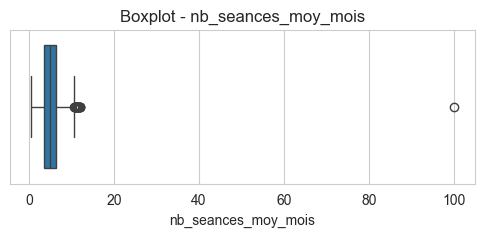


Outliers détectés pour revenu_mensuel :
      revenu_mensuel
47            129.14
1196          131.27
1384          131.10
1765          128.67
1897          129.95
2310          137.18
2398          131.82
2403          137.04
2858          128.58
2957          133.32
4884          132.51
5061          133.50
5607          138.75
5776          999.00
6240          132.98
6520          131.56
6797          133.65
6912          138.15
7562          141.12
8422          131.32
9112          131.63
9279          131.97
9355          128.14
9506          138.10

Nombre d'outliers pour revenu_mensuel : 24


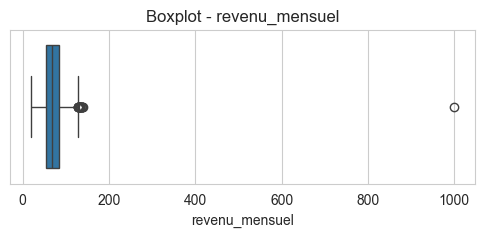

               Colonne  Nb_outliers
0                  age           50
1  nb_seances_moy_mois           23
2       revenu_mensuel           24


In [62]:
# Détection outliers et suppression
colonnes = ['age', 'nb_seances_moy_mois', 'revenu_mensuel']
resume = []
outliers_dict = {}

for colonne in colonnes:

    # Calcul de Q1, Q3 et IQR
    Q1 = df[colonne].quantile(0.25)
    Q3 = df[colonne].quantile(0.75)
    IQR = Q3 - Q1

    # Détection des outliers
    outliers = df[
        (df[colonne] < Q1 - 1.5 * IQR) |
        (df[colonne] > Q3 + 1.5 * IQR)
    ]

    outliers_dict[colonne] = outliers.index

    # Affichage des résultats

    print(f"\n{'='*50}")
    print(f"Outliers détectés pour {colonne} :")
    print(outliers[[colonne]])
    print(f"\nNombre d'outliers pour {colonne} : {len(outliers)}")

    resume.append({
        'Colonne': colonne,
        'Nb_outliers': len(outliers)
    })

    # Boxplot
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[colonne])
    plt.title(f"Boxplot - {colonne}")
    plt.show()

resume = pd.DataFrame(resume)
print(resume)

In [63]:
# lignes à supprimer
lignes_a_supprimer = (
    (df['age'] == df['age'].max()) |
    (df['nb_seances_moy_mois'] == df['nb_seances_moy_mois'].max()) |
    (df['revenu_mensuel'] == df['revenu_mensuel'].max())
)

df[lignes_a_supprimer]

,id_client,age,anciennete_mois,nb_seances_moy_mois,abonnement_premium,coaching,satisfaction,revenu_mensuel,churn
1260,1261,150.0,12,8.4,1,0,7.6,90.10,0
5776,5777,42.0,49,6.7,0,0,5.8,999.00,0
7700,7701,46.0,31,100.0,1,0,5.2,86.37,0


In [64]:
#Suppression
df = df[~lignes_a_supprimer]

<div style="border: 2px solid blue; padding: 10px; border-radius: 8px;">

Nous pouvons voir que les vraies outliers sont les **max** des colonnes **age**, **nb_seances_moy_mois** et **revenu_mensuel**. Ils ont donc été supprimés. En effet pour les autres outliers détectés, les valeurs sont tout à fait possibles.

</div>

#### <u>**Traitement des NaN**</u>

In [65]:
#Colonne satisfaction
df['satisfaction'] = df['satisfaction'].fillna(df['satisfaction'].median())

#Colonne revenu_mensuel
df = df.dropna(subset=['revenu_mensuel'])

#Colonne age
df['age'] = df.groupby('abonnement_premium',observed=True)['age'].transform(lambda x: x.fillna(x.mean()))

#Colonne nb_seances_moy_mois
## Création catégories d'âge
df['categorie_age'] = pd.cut(df['age'],bins=[0, 17, 34, 64, float('inf')],labels=['Enfant', 'Jeune adulte', 'Adulte', 'Senior'])

# Imputation de nb_seances_moy_mois par médiane de la catégorie d'âge
df['nb_seances_moy_mois'] = (df.groupby('categorie_age',observed=True)['nb_seances_moy_mois'].transform(lambda x: x.fillna(x.mean())))

In [66]:
df.isna().sum()

id_client              0
age                    0
anciennete_mois        0
nb_seances_moy_mois    0
abonnement_premium     0
coaching               0
satisfaction           0
revenu_mensuel         0
churn                  0
categorie_age          0
dtype: int64

<div style="border: 2px solid blue; padding: 10px; border-radius: 8px;">

Pour traiter les valeurs manquantes, différentes méthodes d'imputation ont été appliquées en fonction des caractéristiques de chaque variable.

- Les valeurs manquantes de **satisfaction** ont été remplacées par la **mediane** de la variable. Ce choix permet de limiter l'influence des valeurs extrêmes tout en conservant une valeur représentative de la distribution.

- Les valeurs manquantes de **revenu_mensuel** ont été supprimés. Cette colonne étant la variable cible, il vaut mieux ne pas l'imputée afin d’éviter d’entraîner le modèle sur des valeurs estimées plutôt que sur des observations réelles. Si nous avions voulu faire une imputatuion, il aurait fallut remplacer les NaN par la **moyenne calculée au sein de chaque groupe d'abonnement_premium et coaching**, car le revenu peut varier selon le type d'abonnement souscrit. En effet quelqu'un qui a à la fois abonnement premium et coaching rapportera plus qu'une personne ayant soit l'un où l'autre où soit aucun des deux.

- Les valeurs manquantes de **age** ont été remplacées par la **moyenne du groupe correspondant à l'abonnement_premium**. Ce choix est justifié par le fait que les clients disposant d'un abonnement premium sont généralement **plus âgés** que les autres clients car plus de moyens en général.

- Pour **nb_seances_moy_mois**, une variable intermédiaire de **catégorie d'âge** a été créée avec les classes suivantes : **Enfant**, **Jeune adulte**, **Adulte** et **Senior**. Les valeurs manquantes ont ensuite été remplacées par la **moyenne du nombre de séances observée dans chaque catégorie d'âge**, afin de tenir compte des différences de comportement entre les groupes d'âge.

Ces méthodes ont permis de traiter l'ensemble des valeurs manquantes tout en conservant la cohérence des données et les relations potentielles entre les variables.

</d>

In [67]:
#Suppression de la colonne categorie_age
df = df.drop(columns='categorie_age')

#### <u>**Changement de type colonne**</u>

In [68]:
# Variables catégorielles
df['churn'] = df['churn'].astype('category')

# Âge en entier
df['age'] = df['age'].astype(int)

## <span style="color:darkblue"><u>Partie 2 : Modèle 1 - Estimer le Revenu Mensuel</u></span>

#### <u>**Analyse et Modélisation**</u>

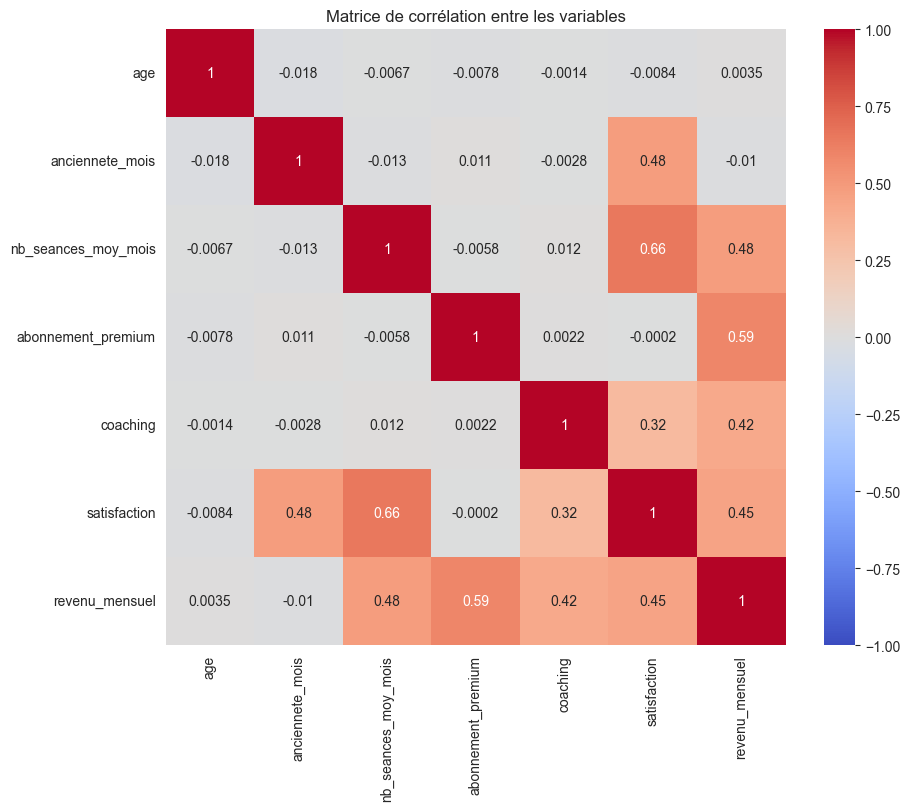


Corrélations avec revenu_mensuel:

revenu_mensuel         1.000000
abonnement_premium     0.589511
nb_seances_moy_mois    0.484372
satisfaction           0.446596
coaching               0.420215
age                    0.003543
anciennete_mois       -0.010498
Name: revenu_mensuel, dtype: float64


In [69]:
# Matrice de corrélation
df_numerique = df.drop(columns=['churn', 'id_client'])
plt.figure(figsize=(10,8))
sns.heatmap(df_numerique.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matrice de corrélation entre les variables')
plt.show()

print("\nCorrélations avec revenu_mensuel:\n")
print(df_numerique.corr()['revenu_mensuel'].sort_values(ascending=False))

<div style="border: 2px solid blue; padding: 10px; border-radius: 8px;">

L'analyse des corrélations montre que **abonnement_premium** est la variable la plus fortement associée au **revenu mensuel généré par client** (*r = 0.59*). Les clients premium ont donc tendance à générer davantage de revenus pour l'entreprise. Le **nombre moyen de séances par mois** (*r = 0.48*), la **satisfaction** (*r = 0.45*) et le **coaching** (*r = 0.42*) présentent également des corrélations positives modérées, suggérant que les clients les plus engagés et les plus satisfaits contribuent davantage au chiffre d'affaires. En revanche, **l'âge** et **l'ancienneté** montrent une corrélation quasi nulle avec le revenu généré, indiquant que ces caractéristiques ont peu d'influence directe sur les revenus. Ces résultats suggèrent que les services premium et l'engagement des clients constituent les principaux leviers pour augmenter le revenu mensuel généré par client.

</div>

#### <u>**Construction et Évaluation du Modèle**</u>

In [70]:
# Cible : revenu_mensuel
X_rev = df.drop(columns=['revenu_mensuel', 'churn', 'id_client'])
y_rev = df['revenu_mensuel']

X_train_rev, X_test_rev, y_train_rev, y_test_rev = train_test_split(X_rev, y_rev, test_size=0.2, random_state=42)

# Modèle
model_rev = LinearRegression()
model_rev.fit(X_train_rev, y_train_rev)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 0.03,-0.02, 4.9 ,24.92,19.38, 0.14]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['age','anciennete_mois','nb_seances_moy_mois','abonnement_premium', 'coaching','satisfaction']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,29.24
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,6


R2 : 0.7618
MSE : 96.92


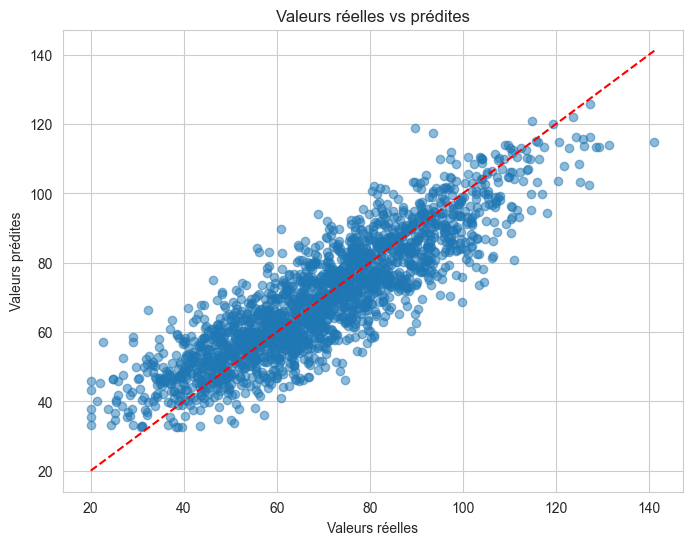

In [71]:
# Evaluation du modèle
y_pred_rev = model_rev.predict(X_test_rev)
r2_rev = r2_score(y_test_rev, y_pred_rev)
mse_rev = mean_squared_error(y_test_rev, y_pred_rev)
print(f"R2 : {r2_rev:.4f}")
print(f"MSE : {mse_rev:.2f}")

# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(y_test_rev, y_pred_rev, alpha=0.5)
plt.plot([y_test_rev.min(), y_test_rev.max()], [y_test_rev.min(), y_test_rev.max()], 'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Valeurs réelles vs prédites")
plt.show()

<div style="border: 2px solid blue; padding: 10px; border-radius: 8px;">

Le modèle présente un coefficient de détermination (R²) de **0.76**, ce qui signifie qu’il explique environ **76 %** de la variance du revenu mensuel généré par client. Cela indique une bonne capacité explicative globale, le modèle parvient donc à capturer une grande partie des facteurs influençant le revenu, même si une part d’environ 24 % reste inexpliquée.

Le modèle est donc performant et exploitable pour une estimation du revenu mensuel.

</d>

#### <u>**Interprétation des Résultats**</u>

In [72]:
# Création d'un DataFrame regroupant le nom des variables et leurs coefficients estimés
df_coeffs = pd.DataFrame({'Variables': X_rev.columns, 'Coefficients': model_rev.coef_})

# Affichage des coefficients triés par importance absolue (du plus influent au moins influent)
print(df_coeffs.sort_values(by='Coefficients',key=abs,ascending=False))

             Variables  Coefficients
3   abonnement_premium     24.924076
4             coaching     19.380706
2  nb_seances_moy_mois      4.902426
5         satisfaction      0.142057
0                  age      0.032391
1      anciennete_mois     -0.015238


<div style="border: 2px solid blue; padding: 10px; border-radius: 8px;">

L’analyse des coefficients du modèle montre que les variables les plus influentes sur le **revenu mensuel généré par client** sont **abonnement_premium** et **coaching**, avec des coefficients respectifs de **24.9** et **19.4**. Cela signifie que, toutes choses égales par ailleurs, le fait d’être client premium est associé à une augmentation moyenne d’environ 25 unités du revenu mensuel généré, et le fait qu'un client souscrive à un coaching est associé à une augmentation moyenne d’environ 19.4 unités du revenu mensuel généré.

Le **nombre de séances mensuelles** a également un impact positif (coefficient=4.94), indiquant qu’une séance supplémentaire par mois est liée à une augmentation moyenne d’environ **4.9 unités monétaires du revenu mensuel généré par client** montrant que les clients plus actifs contribuent davantage au chiffre d’affaires.

En revanche, **la satisfaction**, **l’âge** et **l’ancienneté** ont des coefficients proches de zéro, ce qui suggère qu’ils ont un impact très limité sur le revenu dans ce modèle.

</d>

In [73]:
print("Intercept :", model_rev.intercept_)

Intercept : 29.242868406401094


<div style="border: 2px solid blue; padding: 10px; border-radius: 8px;">

L’**intercept** du modèle est d’environ **29.24**. Cela représente le revenu mensuel généré estimé par le modèle pour un client théorique ayant toutes les variables explicatives à zéro (c’est-à-dire sans abonnement premium, sans coaching, avec 0 séance mensuelle, et des valeurs nulles pour les autres variables continues comme l’âge ou la satisfaction).

Dans la pratique, cette situation n’est pas réaliste (un client avec 0 séance, âge 0, etc.), donc l’intercept n’a pas d’interprétation métier directe. Il sert principalement de **point de base mathématique** à partir duquel le modèle ajuste ses prédictions en fonction des variables explicatives.

</d>

## <span style="color:darkblue"><u>Partie 3 : Modèle 2 - Prédire le Churn</u></span>

#### <u>**Analyse et Modélisation**</u>

In [74]:
df['churn'].value_counts()

churn
0    9349
1     638
Name: count, dtype: int64

<div style="border: 2px solid blue; padding: 10px; border-radius: 8px;">

<u>Répartition de la variable cible **churn** :</u>

| Statut du client | Nombre de clients | Pourcentage |
|:-----------------|:------------------|:------------|
| **0** (Client resté) | 9349              | 93.5 %      |
| **1** (Client ayant churné) | 638               | 6.4 %       |


<u>Interprétation :</u>

- La base de données n'est pas du tout équilibrée :
  - **93.5 %** des clients sont restés fidèles,
  - **6.4 %** ont churnés.<p>


<u>Cela signifie que :</u>

  - Nous aurons besoin de techniques de rééquilibrage (class_weight='balanced') pour entraîner correctement notre modèle de régression logistique par la suite.

</div>

#### <u>**Construction et Évaluation du Modèle LogisticRegression**</u>

In [75]:
# Cible : churn
X_churn = df.drop(columns=['revenu_mensuel', 'churn', 'id_client'])
y_churn = df['churn']

X_train_chu, X_test_chu, y_train_chu, y_test_chu = train_test_split(X_churn, y_churn, test_size=0.2, random_state=42)

# Modèle
model_RLchurn = LogisticRegression(class_weight='balanced',max_iter=1000, random_state=42) #max_iter=1000 car model complexe, on donne plus de tentatives pour un meilleur résulat

model_RLchurn.fit(X_train_chu, y_train_chu)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you migh

In [76]:
# Prédictions sur l'ensemble test
predictions = model_RLchurn.predict(X_test_chu)

# Évaluation complète
accuracy = accuracy_score(y_test_chu, predictions)
precision = precision_score(y_test_chu, predictions)
recall = recall_score(y_test_chu, predictions)
f1 = f1_score(y_test_chu, predictions)

# Affichage des résultats
print(f"Précision globale : {accuracy * 100:.2f}%")
print(f"Précision (précision positive): {precision * 100:.2f}%")
print(f"Recall (rappel des churns) : {recall * 100:.2f}%")
print(f"F1-Score : {f1 * 100:.2f}%")

# Matrice de confusion
conf_matrix = confusion_matrix(y_test_chu, predictions)
print("Matrice de confusion :")
print(conf_matrix)

Précision globale : 80.08%
Précision (précision positive): 23.49%
Recall (rappel des churns) : 79.02%
F1-Score : 36.22%
Matrice de confusion :
[[1487  368]
 [  30  113]]


<div style="border: 2px solid blue; padding: 10px; border-radius: 8px;">

Le modèle atteint une **précision globale de 80.08 %**, ce qui signifie qu’il classe correctement environ 80 % des clients en churn ou non-churn.

La **matrice de confusion** permet d’analyser plus finement ses performances :

- **1487 vrais négatifs (TN)** : le modèle prédit correctement que ces clients ne churnent pas.
- **113 vrais positifs (TP)** : le modèle détecte correctement les clients qui churnent.
- **368 faux positifs (FP)** : le modèle prédit un churn alors que le client ne part pas réellement.
- **30 faux négatifs (FN)** : le modèle ne détecte pas des clients qui churnent réellement.

Le modèle de régression logistique obtient une accuracy de **80.08 %**, ce qui indique une performance globale correcte. Cependant, cette valeur est trompeuse dans un contexte de churn déséquilibré. En effet, le modèle présente une précision faible de **23.49 %**, ce qui signifie qu’une grande proportion des clients prédits comme churn ne le sont pas réellement, entraînant de nombreux faux positifs. En revanche, le recall élevé de **79.02 %** montre que le modèle parvient à détecter la majorité des clients susceptibles de churn, limitant ainsi les faux négatifs. Le F1-score de **36.22 %** traduit un déséquilibre entre la capacité de détection et la fiabilité des prédictions. Ainsi, bien que le modèle soit efficace pour identifier les clients à risque de départ, il manque de précision et génère trop d’alertes inutiles, ce qui limite son efficacité opérationnelle.

<d/>

### <u>**Réalisation d'un modèle Random Forest**</u>

In [77]:
# Création du modèle
model_RFchurn = RandomForestClassifier(class_weight='balanced',random_state=42)

# Entraînement sur l'ensemble d'entraînement
model_RFchurn.fit(X_train_chu, y_train_chu)

# Prédictions sur l'ensemble test
rf_predictions = model_RFchurn.predict(X_test_chu)

# Évaluation complète
rf_accuracy = accuracy_score(y_test_chu, rf_predictions)
rf_precision = precision_score(y_test_chu, rf_predictions)
rf_recall = recall_score(y_test_chu, rf_predictions)
rf_f1 = f1_score(y_test_chu, rf_predictions)

# Affichage des résultats
print(f"Précision globale : {rf_accuracy * 100:.2f}%")
print(f"Precision (précision positive) : {rf_precision * 100:.2f}%")
print(f"Recall (rappel des churns) : {rf_recall * 100:.2f}%")
print(f"F1-Score : {rf_f1 * 100:.2f}%")

# Matrice de confusion
rf_conf_matrix = confusion_matrix(y_test_chu, rf_predictions)
print("Matrice de confusion :")
print(rf_conf_matrix)

Précision globale : 91.74%
Precision (précision positive) : 41.13%
Recall (rappel des churns) : 35.66%
F1-Score : 38.20%
Matrice de confusion :
[[1782   73]
 [  92   51]]


<div style="border: 2px solid blue; padding: 10px; border-radius: 8px;">

Le modèle Random Forest atteint une **accuracy de 91.74 %**, ce qui indique une très bonne performance globale. Cependant, comme pour le modèle précédent, cette métrique est à relativiser dans un contexte de churn déséquilibré.

En effet, la **précision sur la classe churn est de 41.13 %**, ce qui signifie que moins de 4 clients sur 10 prédits comme churn le sont réellement, ce qui génère encore un nombre non négligeable de faux positifs. Le **recall de 35.66 %** est relativement faible, indiquant que le modèle ne parvient à détecter qu’environ un tiers des clients réellement en situation de churn, laissant ainsi une proportion importante de clients à risque non identifiés. Le **F1-score de 38.20 %** confirme ce compromis limité entre précision et rappel.

La matrice de confusion confirme cette analyse : le modèle classe correctement une grande majorité de clients non churn (1782 vrais négatifs), mais ne détecte que 51 churns sur 143 réels, avec 92 faux négatifs et 73 faux positifs. Ainsi, malgré une très bonne accuracy, le modèle reste insuffisant pour un objectif métier de détection du churn, car il manque une part importante des clients susceptibles de partir.

<d/>

### <u>**Choix du model**</u>

<div style="border: 2px solid blue; padding: 10px; border-radius: 8px;">

Bien que le Random Forest présente une meilleure précision globale, la **Régression Logistique** est retenue pour la stratégie de FitNation. En effet, son Rappel de 79.02% (contre seulement 35.66% pour le Random Forest) permet de détecter près des trois quarts des clients sur le départ. Il est préférable ici d'accepter un taux de fausses alertes plus élevé (Précision de 23.49%) plutôt que de laisser s'échapper la majorité des clients à risque sans intervenir.

</div>

### <u>**Application du modèle**</u>

In [78]:
# chargement des données à tester
df_2024 = pd.read_csv("INPUT/clients_2024.csv")
df_2024.head(5)

,id_client,age,anciennete_mois,nb_seances_moy_mois,abonnement_premium,coaching,satisfaction
0,10001,31,12,5.9,1,0,3.6
1,10002,36,2,6.3,0,1,4.0
2,10003,23,6,8.4,0,0,3.4
3,10004,24,11,3.2,1,0,2.0
4,10005,41,3,3.2,0,0,2.7


In [79]:
# suppresison de la colonne Id_client pour que ce soit comme les données entraînées
X_2024 = df_2024.drop(columns=['id_client'])

# probabilité de churn model Regression Logistique
proba_churn = model_RLchurn.predict_proba(X_2024)[:, 1] * 100

# prediction de churn model Regression Logistique
predi_churn = model_RLchurn.predict(X_2024)

# résultats
resultats = pd.DataFrame({
    'id_client': df_2024['id_client'],
    'prediction_churn': predi_churn,
    'probabilite_associee (%)': proba_churn
})

resultats

,id_client,prediction_churn,probabilite_associee (%)
0,10001,1,60.884257
1,10002,1,62.550551
2,10003,0,45.463060
3,10004,1,89.370534
4,10005,1,88.386309
...,...,...,...
1995,11996,1,80.041057
1996,11997,1,90.630928
1997,11998,1,58.098096
1998,11999,1,98.105732


In [80]:
# export du fichier excel
resultats.to_csv("pred_clients_2024_CALLACHAND_Muntasir.csv", index=False)

In [81]:
# Analyse des prédictions
resultats['prediction_churn'].value_counts()

prediction_churn
1    1651
0     349
Name: count, dtype: int64

<div style="border: 2px solid blue; padding: 10px; border-radius: 8px;">

L’application du modèle de Régression Logistique à l’ensemble des clients conduit à l’identification de **1 651 clients à risque de churn** contre **349 clients considérés comme fidèles**. Cette proportion élevée de churns prédits s’explique par le choix d’un modèle privilégiant le rappel (79.02 %), dont l’objectif est de détecter un maximum de clients susceptibles de quitter l’entreprise. En contrepartie, la précision plus faible du modèle (23.49 %) implique qu’une partie importante de ces clients identifiés comme à risque ne résilieront pas réellement leur abonnement. Cette approche reste néanmoins pertinente dans une logique de fidélisation, où il est généralement préférable de cibler davantage de clients potentiellement à risque plutôt que de laisser partir des clients sans action préventive.

</div>

### <u>**Identification clients à risque**</u>

In [82]:
top_20 = resultats.sort_values(by='probabilite_associee (%)', ascending=False).head(20)
print(top_20)

      id_client  prediction_churn  probabilite_associee (%)
1350      11351                 1                 99.007421
941       10942                 1                 98.918403
926       10927                 1                 98.884377
1947      11948                 1                 98.808757
1784      11785                 1                 98.746982
1535      11536                 1                 98.744570
560       10561                 1                 98.724418
183       10184                 1                 98.721617
944       10945                 1                 98.636327
1925      11926                 1                 98.587527
1436      11437                 1                 98.547193
1176      11177                 1                 98.530985
760       10761                 1                 98.520043
357       10358                 1                 98.496160
1591      11592                 1                 98.476227
1783      11784                 1       

## <span style="color:darkblue"><u>Partie 4 : Recommandations stratégiques</u></span>

<div style="border: 2px solid blue; padding: 10px; border-radius: 8px;">

<u>Au vu des résultats, nous savons que :</u>

* Le churn est fortement lié à **l’engagement** du client.
* Les variables les plus liées au revenu sont **abonnement_premium**, **coaching** et **nb_seances_moy_mois**.
* L’objectif métier est de réduire les départs et augmenter le revenu généré par client.

<u>Nous pouvons proposer les recommandations suivantes :</u>

* **Mettre en place une campagne de rétention ciblée pour les clients à risque de churn**

Grâce au modèle de prédiction, l’entreprise peut identifier les clients présentant une forte probabilité de départ et intervenir avant qu’ils ne quittent la salle. Des actions telles que des offres personnalisées, des appels de suivi ou des réductions temporaires peuvent être proposées aux clients les plus à risque afin d’améliorer leur fidélisation. Bien que cette campagne basée sur la Régression Logistique engendre des faux positifs, le faible coût d'envoi d'un email de satisfaction ou d'une relance automatisée rend l'opération rentable dès le premier client sauvé.

* **Encourager l’adoption des abonnements premium**

L’analyse du modèle de régression a montré que l’abonnement premium est le principal facteur associé à une augmentation du revenu mensuel généré par client (+25). La direction marketing pourrait mettre en place des campagnes de promotion ciblées ou des périodes d’essai gratuites afin d’inciter davantage de clients à migrer vers cette offre à plus forte valeur ajoutée.

* **Développer les services de coaching personnalisé**

Le coaching présente un impact positif important sur le revenu généré par les clients (+19.30). Il serait pertinent de promouvoir davantage ce service auprès des adhérents, par exemple via des séances découvertes gratuites, des programmes personnalisés ou des offres groupées avec les abonnements premium.

* **Stimuler la fréquentation des clients moins actifs**

Le nombre moyen de séances mensuelles est également un facteur important du revenu (+4.94). L’entreprise pourrait mettre en place des challenges sportifs, des programmes de fidélité ou des notifications de relance pour encourager les clients à fréquenter davantage la salle. Une augmentation de l’engagement pourrait contribuer à la fois à réduire le churn et à accroître les revenus.

**Conclusion**

Les résultats montrent que les leviers les plus efficaces pour améliorer la performance de l’entreprise sont la fidélisation préventive des clients à risque, la promotion des abonnements premium, le développement du coaching et l’augmentation de la fréquentation des salles. Ces actions sont directement soutenues par les résultats des modèles construits et constituent des recommandations concrètes et activables pour la direction marketing.

<d/>

<div style="text-align: center;">

<h1 style="color:blue; font-size:50px; font-weight:bold;">
FIN
</h1>


</div>